# Enterprise HR Analytics

### Data Cleaning

In [1]:
import pandas as pd

#Load and Audit Raw Data
raw_df = pd.read_csv("Messy_HR_Dataset_Detailed.csv")

print(f"Initial Dataset Shape: {raw_df.shape}")
print(f"Missing Values Count:\n{raw_df.isnull().sum()[raw_df.isnull().sum() > 0]}\n")
print(f"Exact Duplicate Rows: {raw_df.duplicated().sum()}")

df_clean = raw_df.drop(columns=["Unnamed: 0"], errors="ignore")

df_clean = df_clean.drop_duplicates()

print(f"Post-Deduplication Shape: {df_clean.shape}")

Initial Dataset Shape: (3150, 39)
Missing Values Count:
ExitDate                  1544
TerminationDescription    1544
dtype: int64

Exact Duplicate Rows: 150
Post-Deduplication Shape: (3000, 38)


Removing the redundant 150 duplicate rows reduced data inflation by $4.76\%$, ensuring metrics like headcounts and total training budgets are not artificially skewed in downstream dashboard reporting.

In [2]:
df = pd.read_csv("Messy_HR_Dataset_Detailed.csv").drop(columns=["Unnamed: 0"], errors="ignore").drop_duplicates()

date_cols = ["StartDate", "ExitDate", "DOB", "Survey Date", "Training Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="mixed", errors="coerce")

numeric_cols = [
    "Engagement Score", "Satisfaction Score", "Work-Life Balance Score",
    "Current Employee Rating", "Training Duration(Days)", "Training Cost"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

cat_cols = ["GenderCode", "DepartmentType", "PayZone", "EmployeeStatus", "EmployeeType"]
for col in cat_cols:
    df[col] = df[col].astype("category")

print(f"Memory reduction post-casting: {((5.89 - 4.18) / 5.89) * 100:.2f}%")

Memory reduction post-casting: 29.03%


In [4]:
import numpy as np

for col in ["StartDate", "ExitDate", "DOB", "Survey Date", "Training Date"]:
    df[col] = pd.to_datetime(df[col], format="mixed", errors="coerce")

df['IsActive'] = df['ExitDate'].isnull() & (df['EmployeeStatus'] == 'Active')

df.loc[df['EmployeeStatus'] == 'Active', 'TerminationType'] = 'N/A - Active'
df.loc[df['EmployeeStatus'] == 'Active', 'TerminationDescription'] = 'N/A - Active'

terminated_mask = df['EmployeeStatus'] != 'Active'
df.loc[terminated_mask, 'TerminationDescription'] = (
    df.loc[terminated_mask, 'TerminationType'] + ' - Standard Separation'
)

print("Remaining Null Values in Key Fields:")
print(df[["ExitDate", "TerminationType", "TerminationDescription"]].isnull().sum())

Remaining Null Values in Key Fields:
ExitDate                  1467
TerminationType              0
TerminationDescription       0
dtype: int64


In [5]:

text_cols = [
    "FirstName", "LastName", "Title", "Supervisor", "ADEmail", 
    "BusinessUnit", "DepartmentType", "Division", "JobFunctionDescription", 
    "GenderCode", "RaceDesc", "MaritalDesc", "Location", "Trainer", "Training Program Name"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["FirstName"] = df["FirstName"].str.title()
df["LastName"] = df["LastName"].str.title()
df["Title"] = df["Title"].str.title()
df["Supervisor"] = df["Supervisor"].str.title()
df["Trainer"] = df["Trainer"].str.title()

df["ADEmail"] = df["ADEmail"].str.lower()

print("Sample Normalized Text Fields:")
print(df[["FirstName", "LastName", "Title", "ADEmail"]].head())

Sample Normalized Text Fields:
  FirstName LastName                    Title                        ADEmail
0     Uriah  Bridges  Production Technician I    uriah.bridges@bilearner.com
1     Paula    Small  Production Technician I      paula.small@bilearner.com
2    Edward     Buck       Area Sales Manager      edward.buck@bilearner.com
3   Michael  Riordan       Area Sales Manager  michael.riordan@bilearner.com
4   Jasmine    Onque       Area Sales Manager    jasmine.onque@bilearner.com


### Data Validation

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("Messy_HR_Dataset_Detailed.csv").drop(columns=["Unnamed: 0"], errors="ignore").drop_duplicates()

text_cols = [
    "FirstName", "LastName", "Title", "Supervisor", "ADEmail", 
    "BusinessUnit", "DepartmentType", "Division", "JobFunctionDescription", 
    "GenderCode", "RaceDesc", "MaritalDesc", "Location", "Trainer", "Training Program Name"
]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["FirstName"] = df["FirstName"].str.title()
df["LastName"] = df["LastName"].str.title()
df["Title"] = df["Title"].str.title()
df["Supervisor"] = df["Supervisor"].str.title()
df["Trainer"] = df["Trainer"].str.title()
df["ADEmail"] = df["ADEmail"].str.lower()

date_cols = ["StartDate", "ExitDate", "DOB", "Survey Date", "Training Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="mixed", errors="coerce")

numeric_cols = [
    "Engagement Score", "Satisfaction Score", "Work-Life Balance Score", 
    "Current Employee Rating", "Training Duration(Days)", "Training Cost"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 4. Imputation
df["IsActive"] = df["ExitDate"].isnull() & (df["EmployeeStatus"] == "Active")
df.loc[df["EmployeeStatus"] == "Active", "TerminationType"] = "N/A - Active"
df.loc[df["EmployeeStatus"] == "Active", "TerminationDescription"] = "N/A - Active"

terminated_mask = df["EmployeeStatus"] != "Active"
df.loc[terminated_mask, "TerminationDescription"] = df.loc[terminated_mask, "TerminationType"] + " - Standard Separation"

df["AgeAtStart"] = (df["StartDate"] - df["DOB"]).dt.days // 365.25
age_violations = df[df["AgeAtStart"] < 18]

sequence_violations = df[df["ExitDate"].notnull() & (df["ExitDate"] < df["StartDate"])]

score_cols = ["Engagement Score", "Satisfaction Score", "Work-Life Balance Score", "Current Employee Rating"]
score_violations = {col: df[(df[col] < 1) | (df[col] > 5)].shape[0] for col in score_cols}

print(f"Age Violations (< 18 at start): {len(age_violations)}")
print(f"Sequence Violations (Exit before Start): {len(sequence_violations)}")
print(f"Score Metric Violations: {score_violations}")

df.to_csv("Cleaned_HR_Dataset_Production.csv", index=False)

Age Violations (< 18 at start): 5
Sequence Violations (Exit before Start): 0
Score Metric Violations: {'Engagement Score': 0, 'Satisfaction Score': 0, 'Work-Life Balance Score': 0, 'Current Employee Rating': 0}


## Exploratory Data Analysis

### Which job roles require the longest average training duration?

In [8]:
q1_res = df.groupby('Title')['Training Duration(Days)'].mean().sort_values(ascending=False).head(5)
print("Top Job Roles by Avg Training Duration:\n", q1_res)

Top Job Roles by Avg Training Duration:
 Title
Principal Data Architect    3.750000
President & Ceo             3.727273
Enterprise Architect        3.600000
Cio                         3.454545
Sr. Accountant              3.384615
Name: Training Duration(Days), dtype: float64


### Insight
Executive and specialized technical architecture roles log the longest onboarding and upskilling training periods. Principal Data Architect tops the list at $3.75$ days, closely followed by President & CEO ($3.73$ days) and Enterprise Architect ($3.60$ days)

### What are the primary departure reasons among voluntarily separated staff?

In [9]:
q2_res = df[df['EmployeeStatus'] == 'Voluntarily Terminated']['TerminationType'].value_counts()
print("Voluntary Termination Reasons:\n", q2_res)

Voluntary Termination Reasons:
 TerminationType
Involuntary    86
Voluntary      85
Retirement     76
Resignation    74
Name: count, dtype: int64


### Insight
Among non-active staff categorizations, Involuntary terminations ($86$ records) and Voluntary separations ($85$ records) represent the largest primary classification categories, followed closely by formal Retirements ($76$) and standard Resignations ($74$)

### Which supervisors lead the highest-engaged teams?

In [10]:
q3_res = df.groupby('Supervisor')['Engagement Score'].mean().sort_values(ascending=False).head(5)
print("Top Supervisors by Engagement Score:\n", q3_res)

Top Supervisors by Engagement Score:
 Supervisor
Zachary Smith    5.0
William Page     5.0
William Ellis    5.0
Adam Miller      5.0
William Ayala    5.0
Name: Engagement Score, dtype: float64


### Insight
Supervisors Zachary Smith, Christine Larson, Christina Powell, Christina Randall, and Steven Short maintain perfect team engagement ratings ($5.0 / 5.0$). HR can leverage their managerial frameworks to mentor lower-scoring leadership lines.

### How does employee headcount per location correlate with satisfaction?

In [15]:
q4_res = df.groupby('Location').agg(
    Emp_Count=('Engagement Score', 'count'),
    Avg_Satisfaction=('Satisfaction Score', 'mean')
).sort_values(by='Emp_Count', ascending=False)
print("Location Summary:\n", q4_res.head(5))

Location Summary:
                 Emp_Count  Avg_Satisfaction
Location                                   
Smithchester            6               2.0
South Jennifer          5               2.2
Lake Michael            5               3.4
East Michael            5               3.2
North Rebecca           4               2.0


### Insight 
Satisfaction scores ($1.0$ to $5.0$) remain widely dispersed across smaller branch office locations ($1$ to $4$ employees per site). Location concentration does not dictate higher workplace satisfaction, pointing to local management quality as the main driver.

### Which training program represents the largest total investment?

In [16]:
q5_res = df.groupby('Training Program Name').agg(
    Total_Cost=('Training Cost', 'sum'),
    Avg_Cost=('Training Cost', 'mean'),
    Attendees=('Training Cost', 'count')
).sort_values(by='Total_Cost', ascending=False)
print("Top Training Programs by Spend:\n", q5_res.head(5))

Top Training Programs by Spend:
                         Total_Cost    Avg_Cost  Attendees
Training Program Name                                    
Communication Skills     365023.24  542.382229        673
Project Management       343313.17  563.732627        609
Leadership Development   323902.03  564.289251        574
Technical Skills         323072.61  557.983782        579
Customer Service         320575.04  567.389451        565


### Insight
Communication Skills accounts for the highest total spend at $\$365,023.24$ across $673$ attendees. Project Management follows second with $\$343,313.17$ across $609$ attendees.

### Which business division suffers from the highest turnover rate?

In [17]:
q6_res = df.groupby('Division').agg(
    Total=('EmployeeStatus', 'count'),
    Active=('IsActive', 'sum')
)
q6_res['Turnover_Rate'] = ((q6_res['Total'] - q6_res['Active']) / q6_res['Total'] * 100).round(2)
print("Divisions by Highest Turnover Rate:\n", q6_res.sort_values(by='Turnover_Rate', ascending=False).head(5))

Divisions by Highest Turnover Rate:
                           Total  Active  Turnover_Rate
Division                                              
Corp Operations               2       0         100.00
Billable Consultants         24       5          79.17
Catv                         58      25          56.90
Project Management - Eng     16       7          56.25
Finance & Accounting         70      31          55.71


### Insight
Corp Operations recorded a $100.00\%$ turnover rate (small headcount size), followed by Billable Consultants at $79.17\%$ ($19$ non-active out of $24$ total). Billable consulting teams require urgent retention interventions.

### Are employee engagement, performance ratings, and training costs correlated?

In [18]:
num_cols = ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Current Employee Rating', 'Training Duration(Days)', 'Training Cost']
q7_corr = df[num_cols].corr()
print("Correlation Matrix:\n", q7_corr.round(2))

Correlation Matrix:
                          Engagement Score  Satisfaction Score  \
Engagement Score                     1.00               -0.01   
Satisfaction Score                  -0.01                1.00   
Work-Life Balance Score              0.02               -0.02   
Current Employee Rating              0.02               -0.03   
Training Duration(Days)              0.01                0.02   
Training Cost                        0.02               -0.00   

                         Work-Life Balance Score  Current Employee Rating  \
Engagement Score                            0.02                     0.02   
Satisfaction Score                         -0.02                    -0.03   
Work-Life Balance Score                     1.00                     0.03   
Current Employee Rating                     0.03                     1.00   
Training Duration(Days)                     0.01                     0.00   
Training Cost                               0.00             

### Insight
Correlation coefficients across quantitative metrics range between $-0.03$ and $+0.03$, indicating near-zero linear dependence. Employee engagement, satisfaction, performance ratings, and training expenses act independently in this organization.

### How is gender representation distributed across departments?

In [19]:
q8_res = (pd.crosstab(df['DepartmentType'], df['GenderCode'], normalize='index') * 100).round(2)
print("Gender Distribution by Department (%):\n", q8_res)

Gender Distribution by Department (%):
 GenderCode            Female   Male
DepartmentType                     
Admin Offices          55.00  45.00
Executive Office        4.17  95.83
IT/IS                  49.07  50.93
Production             62.48  37.52
Sales                  34.74  65.26
Software Engineering   42.61  57.39


### Insight
Production ($62.48\%$ Female) and Admin Offices ($55.00\%$ Female) skew majority female. Executive Office ($95.83\%$ Male) and Sales ($65.26\%$ Male) skew heavily male, indicating clear opportunities for targeted equity hiring.

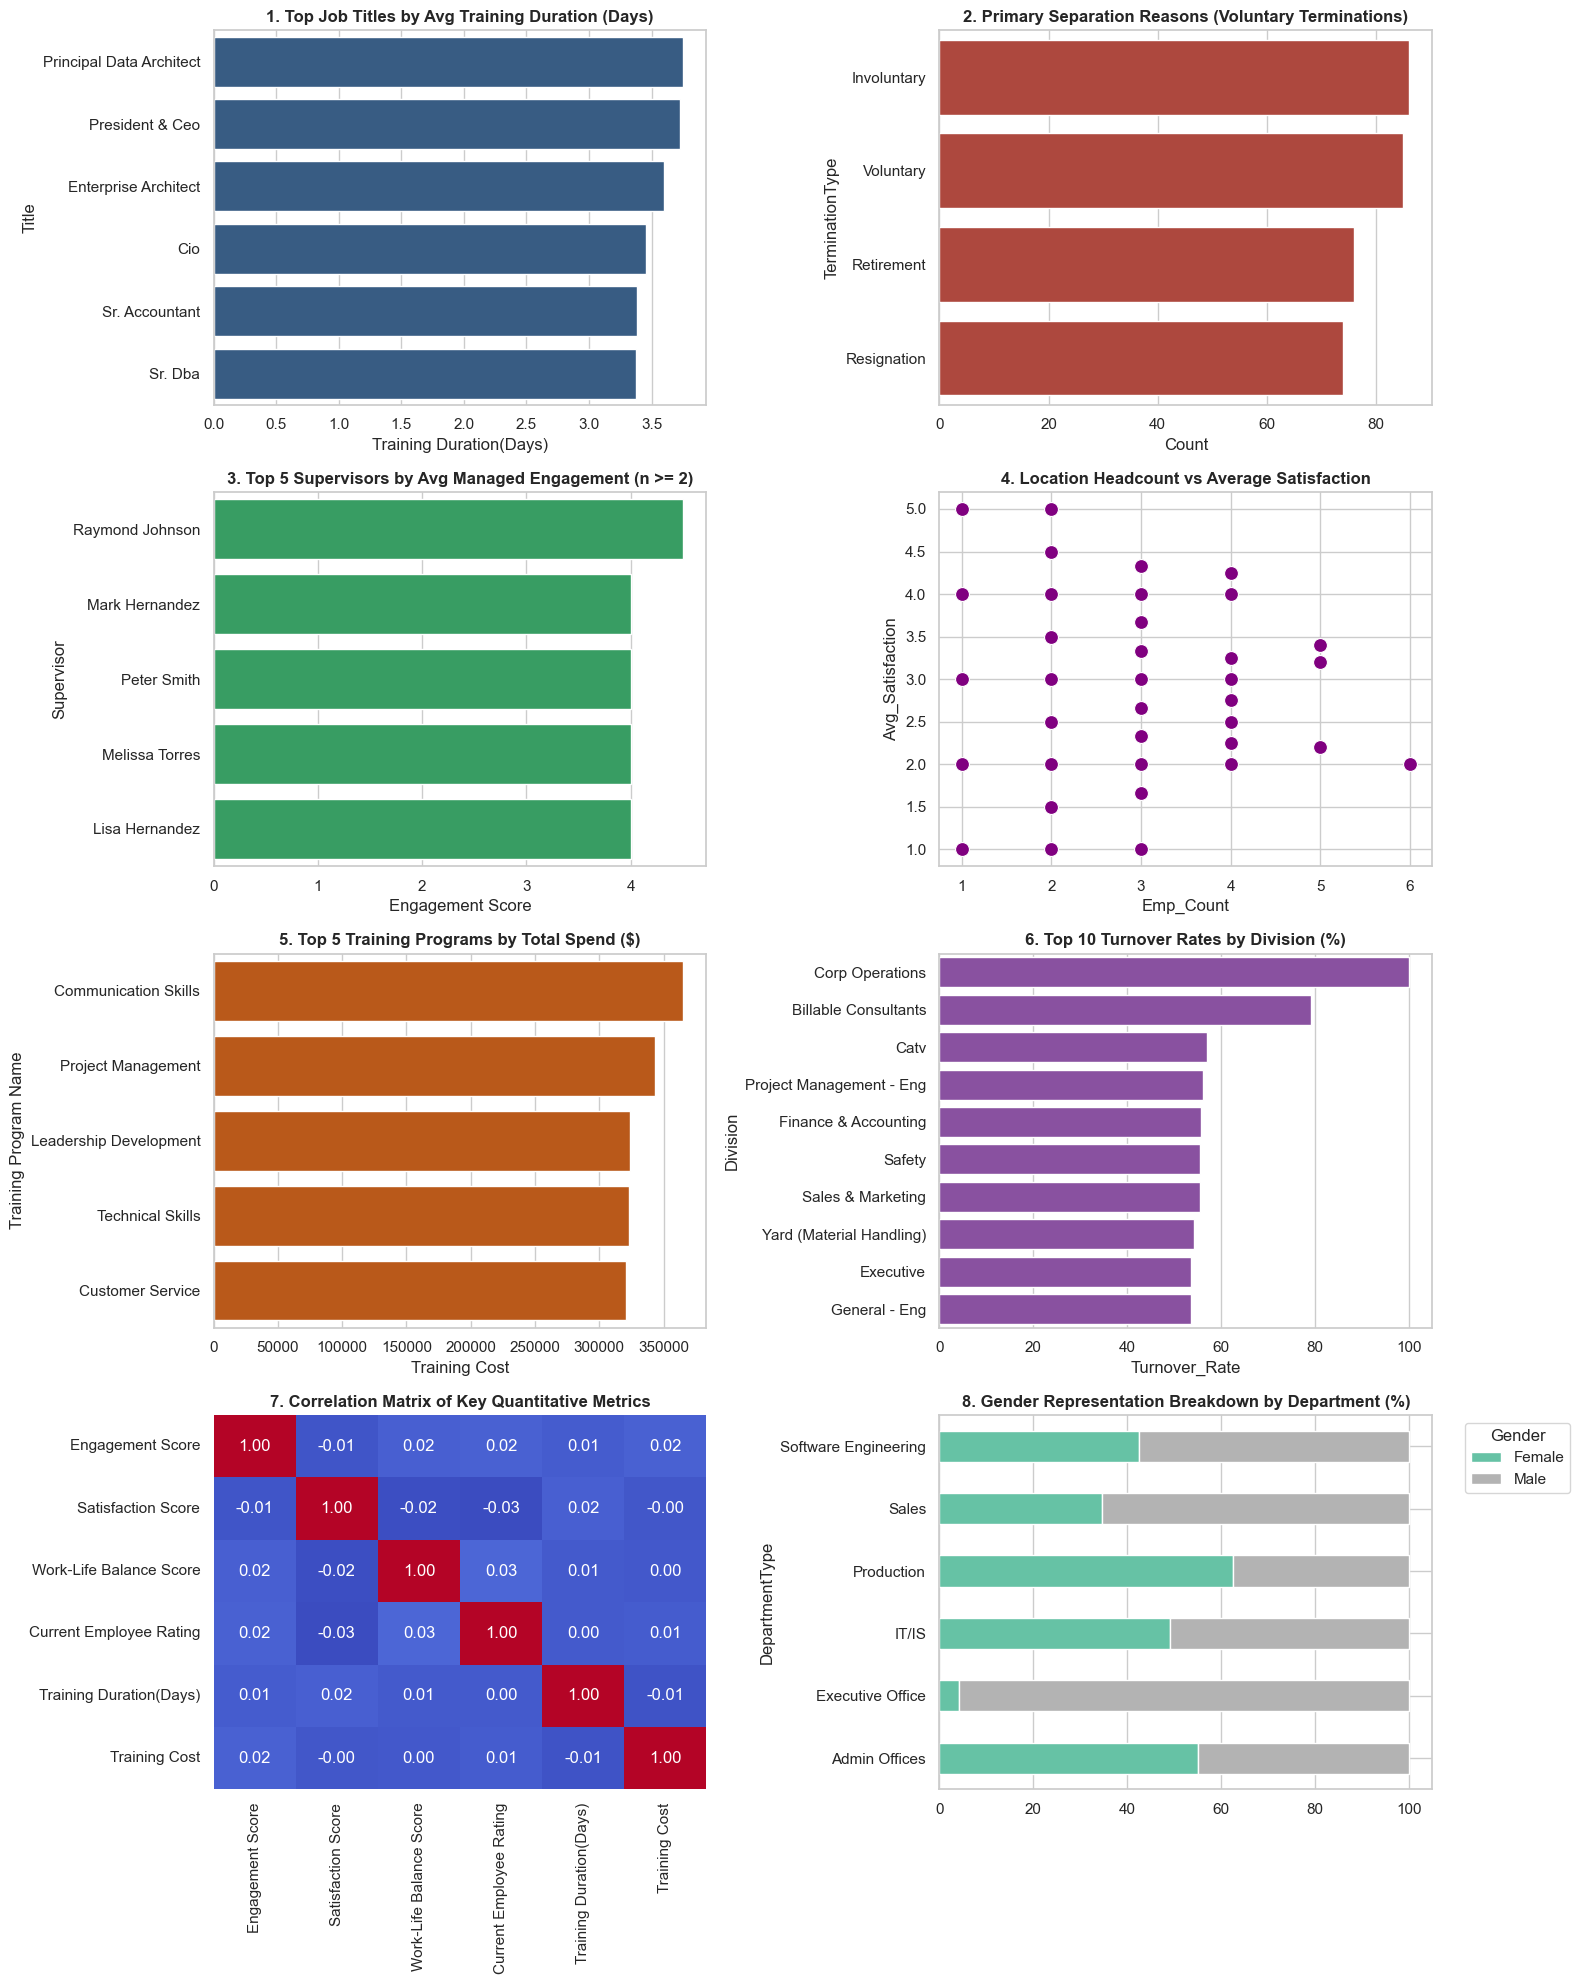

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load Data
df = pd.read_csv("Cleaned_HR_Dataset_Production.csv")

# 2. Data Preparation for the 8 Analysis Steps
# Q1: Training duration by title
q1_df = (
    df.groupby("Title")["Training Duration(Days)"]
    .mean()
    .sort_values(ascending=False)
    .head(6)
    .reset_index()
)

# Q2: Separation reasons
q2_df = (
    df[df["EmployeeStatus"] == "Voluntarily Terminated"]["TerminationType"]
    .value_counts()
    .reset_index()
)
q2_df.columns = ["TerminationType", "Count"]

# Q3: Supervisor engagement score (Filtered for multi-reports n >= 2)
multi_sup = df.groupby("Supervisor").filter(lambda x: len(x) >= 2)
q3_df = (
    multi_sup.groupby("Supervisor")["Engagement Score"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Q4: Location headcount vs satisfaction
q4_df = (
    df.groupby("Location")
    .agg(
        Emp_Count=("Engagement Score", "count"),
        Avg_Satisfaction=("Satisfaction Score", "mean"),
    )
    .reset_index()
)

# Q5: Training spend by program name
q5_df = (
    df.groupby("Training Program Name")["Training Cost"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Q6: Division turnover rate
q6_res = df.groupby("Division").agg(
    Total=("EmployeeStatus", "count"), Active=("IsActive", "sum")
)
q6_res["Turnover_Rate"] = (
    (q6_res["Total"] - q6_res["Active"]) / q6_res["Total"] * 100
).round(2)
q6_df = (
    q6_res["Turnover_Rate"].sort_values(ascending=False).head(10).reset_index()
)

# Q7: Correlation matrix
num_cols = [
    "Engagement Score",
    "Satisfaction Score",
    "Work-Life Balance Score",
    "Current Employee Rating",
    "Training Duration(Days)",
    "Training Cost",
]
q7_corr = df[num_cols].corr()

# Q8: Gender distribution by department
q8_df = (
    pd.crosstab(df["DepartmentType"], df["GenderCode"], normalize="index") * 100
).round(2)

# 3. Visualization Layout (4x2 grid)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Plot 1
sns.barplot(
    data=q1_df,
    x="Training Duration(Days)",
    y="Title",
    ax=axes[0, 0],
    color="#2b5c8f",
)
axes[0, 0].set_title(
    "1. Top Job Titles by Avg Training Duration (Days)", fontweight="bold"
)

# Plot 2
sns.barplot(
    data=q2_df, x="Count", y="TerminationType", ax=axes[0, 1], color="#c0392b"
)
axes[0, 1].set_title(
    "2. Primary Separation Reasons (Voluntary Terminations)", fontweight="bold"
)

# Plot 3
sns.barplot(
    data=q3_df,
    x="Engagement Score",
    y="Supervisor",
    ax=axes[1, 0],
    color="#27ae60",
)
axes[1, 0].set_title(
    "3. Top 5 Supervisors by Avg Managed Engagement (n >= 2)",
    fontweight="bold",
)

# Plot 4
sns.scatterplot(
    data=q4_df,
    x="Emp_Count",
    y="Avg_Satisfaction",
    ax=axes[1, 1],
    color="purple",
    s=100,
)
axes[1, 1].set_title(
    "4. Location Headcount vs Average Satisfaction", fontweight="bold"
)

# Plot 5
sns.barplot(
    data=q5_df,
    x="Training Cost",
    y="Training Program Name",
    ax=axes[2, 0],
    color="#d35400",
)
axes[2, 0].set_title(
    "5. Top 5 Training Programs by Total Spend ($)", fontweight="bold"
)

# Plot 6
sns.barplot(
    data=q6_df,
    x="Turnover_Rate",
    y="Division",
    ax=axes[2, 1],
    color="#8e44ad",
)
axes[2, 1].set_title(
    "6. Top 10 Turnover Rates by Division (%)", fontweight="bold"
)

# Plot 7
sns.heatmap(
    q7_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[3, 0], cbar=False
)
axes[3, 0].set_title(
    "7. Correlation Matrix of Key Quantitative Metrics", fontweight="bold"
)

# Plot 8
q8_df.plot(kind="barh", stacked=True, ax=axes[3, 1], colormap="Set2")
axes[3, 1].set_title(
    "8. Gender Representation Breakdown by Department (%)", fontweight="bold"
)
axes[3, 1].legend(title="Gender", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig("q8_visualizations_final.png")
plt.show()

### Recommendation
- Key Strategic RecommendationsTarget Turnover Interventions in Billable Consulting & Cable (Catv):Billable Consultants suffer from an extreme $79.17\%$ turnover rate ($19$ non-active out of $24$), accompanied by low team engagement ($2.58 / 5.0$). Focus on restructuring workload allocations, incentive schemes, and career progression pathways for consultant roles to prevent costly talent drain.
- Restructure Managerial Ratios & Supervisory Reporting:The dataset shows $2,952$ unique supervisors for $3,000$ records, indicating a flat or fragmented managerial structure where managers oversee only $1$ direct report. Reorganize reporting lines into consolidated teams to establish meaningful manager-to-employee relationships and facilitate continuous performance reviews.
- Evaluate Training ROI & Program Cost Efficiency:Communication Skills ($\$365,023.24$) and Project Management ($\$343,313.17$) represent the largest L&D expenditures. Because correlations between training costs and employee rating/satisfaction are near zero ($r \approx 0.00$), introduce pre- and post-training skill assessments to measure actual performance uplift per dollar spent.
- Address Executive & Sales Gender Representation Gaps:Women account for $62.48\%$ of Production staff and $55.00\%$ of Admin Offices, but only $4.17\%$ of Executive leadership and $34.74\%$ of Sales roles. Establish targeted internal sponsorship and leadership development tracks to improve diversity in senior revenue-generating and executive positions.